# Imports and Paths

In [1]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
import hdf5plugin  # to read the compressed data
import os
import gc
import sys
import torch
from torch.utils.data import DataLoader, Subset, Dataset as TorchDataset
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from tqdm.auto import tqdm
import stable_worldmodel as swm  # to load and run LeWM
from stable_worldmodel.data.formats.hdf5 import HDF5Dataset
import stable_pretraining as spt

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Constants

# Paths and Helper Imports

In [2]:
here = Path.cwd().resolve()
REPO_ROOT = next(
    p for p in [here, *here.parents]
    if (p / "scripts" / "download_data.py").is_file()
)
print("REPO_ROOT", REPO_ROOT)

LEWM_DIR = REPO_ROOT / "third_party" / "le-wm"
if str(LEWM_DIR) not in sys.path:
    sys.path.insert(0, str(LEWM_DIR))

from utils import get_column_normalizer, get_img_preprocessor

H5_PATH = REPO_ROOT / "data" / "processed" / "pusht_expert_train.h5"
os.environ["STABLEWM_HOME"] = str(REPO_ROOT / "data" / "stablewm")  # assign, not setdefault

device = "cuda" if torch.cuda.is_available() else "cpu"
model = swm.policy.AutoCostModel("pusht/lewm").to(device).eval()

REPO_ROOT /workspace/Safety-Dial
10:21:26 | INFO  | __init__.py | JAX version 0.10.2 available.
10:21:29 | INFO  | atomic_chec~| [atomic_save] installed crash-safe checkpoint plugin (write to sibling .tmp + fsync + atomic rename)


# Helper Funcs

In [3]:
# We use the same normalisation that they use in their pipeline during training
prep = get_img_preprocessor(source="pixels", target="pixels", img_size=224)

def pixels_to_tensor(frames_hwc):
    model_device = next(model.parameters()).device
    xs = []
    for f in frames_hwc:
        sample = {"pixels": f}
        prep(sample)
        xs.append(sample["pixels"])
    return torch.stack(xs, 0).unsqueeze(0).to(model_device)

#It get's super annoying when you open an already opened hd5 so
def closeh5():
    g = globals()
    f = g.get("file")
    if f is not None:
        f.close()

#To convert from that clip to the global row in the hdf5
def clip_to_global_row(dataset, clip_idx):
    ep, start = dataset.clip_indices[clip_idx]
    return int(dataset.offsets[ep] + start)

# Prepping the data

In [4]:
#So initially did some random sampling but coz hdf5 is uncompressed and indexes scattered, takes long
# dataset = HDF5Dataset(
#     path=str(H5_PATH),
#     num_steps=1, #One frame per sample
#     frameskip=1, #Basically the temporal stride
#     keys_to_load=["pixels", "state"], #We only need these to train the probe
#     keys_to_cache=["state"], #This loads into RAM, pixels too big
#     transform=prep)

# MAX_SAMPLES = 50_000 #Theres something like 2.3m 50k should suffice
# #We sort because hdf5 reads faster when sequential
# rng = np.random.default_rng(0)
# idx = rng.choice(len(dataset), size=min(MAX_SAMPLES, len(dataset)), replace=False)
# idx.sort()

In [5]:
closeh5()

# # We simply use the first 50_000 samples
# MAX_SAMPLES = 50_000
# rng = np.random.default_rng(0)

# # Sequential read, much faster than random fancy indexing
# with h5py.File(H5_PATH, "r") as f:
#     pixels_cache = f["pixels"][:MAX_SAMPLES]       # (50000, 224, 224, 3) uint8
#     # coords_cache = f["state"][:MAX_SAMPLES, 2:4]   # (50000, 2) block_x, block_y #This is for block
#     coords_cache = f["state"][:MAX_SAMPLES, 0:2]  # pusher_x, pusher_y

MAX_SAMPLES = 100_000
N_CHUNKS = 100
CHUNK_SIZE = MAX_SAMPLES // N_CHUNKS
rng = np.random.default_rng(0)

with h5py.File(H5_PATH, "r") as f:
    total = len(f["pixels"])
    starts = np.linspace(
        0,
        total - CHUNK_SIZE,
        N_CHUNKS,
        dtype=int,
    )

    pixels_cache = np.concatenate([
        f["pixels"][s:s + CHUNK_SIZE]
        for s in starts
    ])

    coords_cache = np.concatenate([
        f["state"][s:s + CHUNK_SIZE, :2]
        for s in starts
    ])

print(f"{pixels_cache.nbytes / 1e9:.2f} GB pixels loaded")
print(pixels_cache.shape, coords_cache.shape)

# Random train/test split in RAM
perm = rng.permutation(MAX_SAMPLES)
n_train = int(0.8 * MAX_SAMPLES)
train_rel = perm[:n_train]
test_rel = perm[n_train:]

15.05 GB pixels loaded
(100000, 224, 224, 3) (100000, 2)


# Creating the Dataloaders

In [6]:
class CachedPushTSamples(TorchDataset):
    def __init__(self, pixels_u8, coords, transform):
        self.pixels = pixels_u8
        self.coords = coords
        self.transform = transform

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, i):
        # match HDF5Dataset: (1, H, W, C) -> (1, C, H, W), then prep (LeWM expects channels first)
        x = torch.from_numpy(self.pixels[i:i+1]).permute(0, 3, 1, 2)
        sample = {"pixels": x, "state": torch.from_numpy(self.coords[i:i+1])}
        return self.transform(sample) if self.transform else sample

cached = CachedPushTSamples(pixels_cache, coords_cache, prep)

loader_kwargs = dict(batch_size=512, num_workers=0, pin_memory=True, shuffle=False)
train_loader = DataLoader(Subset(cached, train_rel.tolist()), **loader_kwargs)
test_loader  = DataLoader(Subset(cached, test_rel.tolist()),  **loader_kwargs)

batch = next(iter(train_loader))
print(batch["pixels"].shape, batch["state"].shape)

torch.Size([512, 1, 3, 224, 224]) torch.Size([512, 1, 2])


# Encoding the frames

In [7]:
@torch.inference_mode()
def encode_loader(loader, desc="encode"):
    zs, ys = [], []
    for batch in tqdm(loader, desc=desc, total=len(loader)):
        pixels = batch["pixels"].to(device, non_blocking=True)
        y = batch["state"][:, 0].float().numpy()          # (B, 2) pusher xy
        z = model.encode({"pixels": pixels})["emb"][:, 0].cpu().numpy()  # (B, 192)
        zs.append(z)
        ys.append(y)
    return np.concatenate(zs), np.concatenate(ys)

Z_train, Y_train = encode_loader(train_loader, desc="train")
Z_test, Y_test = encode_loader(test_loader, desc="test")
print(Z_train.shape, Y_train.shape, Z_test.shape, Y_test.shape)

test: 100%|██████████| 40/40 [00:53<00:00,  1.33s/it]

(80000, 192) (80000, 2) (20000, 192) (20000, 2)


In [8]:
# Now we can free the pixel mem
del pixels_cache, cached, train_loader, test_loader
gc.collect()
if device == "cuda":
    del model
    torch.cuda.empty_cache()

# Training Ridge Regression model

Linear probe: LeWM latents → pusher (x, y)
  samples : 20,000 test / 80,000 train
  alpha   : 1.0
  R²      : 0.9653  (x: 0.9689, y: 0.9616)
  RMSE    : 18.93 px  (x: 18.15, y: 19.67)
  Ridge holdout margin : 37.86 px  (2 × RMSE; not used for planning)
  path substeps   : 5


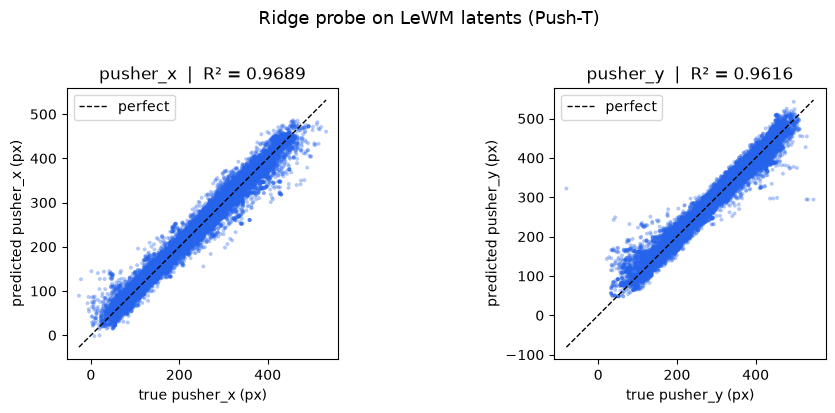

In [9]:
pusher_probe = Ridge(alpha=1.0).fit(Z_train, Y_train)

Y_pred = pusher_probe.predict(Z_test)

r2 = r2_score(Y_test, Y_pred)
r2_x = r2_score(Y_test[:, 0], Y_pred[:, 0])
r2_y = r2_score(Y_test[:, 1], Y_pred[:, 1])
rmse = np.sqrt(np.mean((Y_test - Y_pred) ** 2))
rmse_x = np.sqrt(np.mean((Y_test[:, 0] - Y_pred[:, 0]) ** 2))
rmse_y = np.sqrt(np.mean((Y_test[:, 1] - Y_pred[:, 1]) ** 2))

RIDGE_MARGIN = 2.0 * float(rmse)
N_SUBSTEPS = 5

print("Linear probe: LeWM latents → pusher (x, y)")
print(f"  samples : {len(Y_test):,} test / {len(Y_train):,} train")
print(f"  alpha   : {pusher_probe.alpha}")
print(f"  R²      : {r2:.4f}  (x: {r2_x:.4f}, y: {r2_y:.4f})")
print(f"  RMSE    : {rmse:.2f} px  (x: {rmse_x:.2f}, y: {rmse_y:.2f})")
print(f"  Ridge holdout margin : {RIDGE_MARGIN:.2f} px  (2 × RMSE; not used for planning)")
print(f"  path substeps   : {N_SUBSTEPS}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, dim, name, r2_dim in zip(
    axes, [0, 1], ["pusher_x", "pusher_y"], [r2_x, r2_y]
):
    ax.scatter(Y_test[:, dim], Y_pred[:, dim], s=8, alpha=0.35, c="#2563eb", edgecolors="none")
    lo = min(Y_test[:, dim].min(), Y_pred[:, dim].min())
    hi = max(Y_test[:, dim].max(), Y_pred[:, dim].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect")
    ax.set_xlabel(f"true {name} (px)")
    ax.set_ylabel(f"predicted {name} (px)")
    ax.set_title(f"{name}  |  R² = {r2_dim:.4f}")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="upper left")

fig.suptitle("Ridge probe on LeWM latents (Push-T)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# MLP Probe

epoch   1/80  train MSE = 56037.90
epoch  10/80  train MSE = 126.32
epoch  20/80  train MSE = 52.93
epoch  30/80  train MSE = 23.35
epoch  40/80  train MSE = 14.68
epoch  50/80  train MSE = 11.41
epoch  60/80  train MSE = 9.85
epoch  70/80  train MSE = 8.87
epoch  80/80  train MSE = 8.35
MLP probe: LeWM latents → pusher (x, y)
  samples : 20,000 test / 80,000 train
  arch    : 192 → 256 → 128 → 2
  R²      : 0.9990  (x: 0.9992, y: 0.9989)
  MSE     : 9.94   (paper reports this)
  Pearson : 0.9995  (x: 0.9996, y: 0.9995)
  RMSE    : 3.15 px  (x: 2.99, y: 3.31)


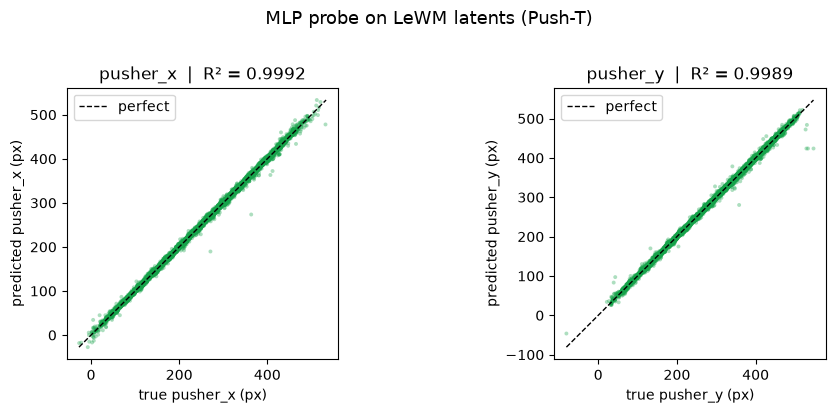

In [10]:
class MLPProbe(torch.nn.Module):
    """Non-linear probe: z (192) -> pusher (x, y)."""
    def __init__(self, in_dim=192, hidden=(256, 128), out_dim=2):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [torch.nn.Linear(d, h), torch.nn.ReLU()]
            d = h
        layers.append(torch.nn.Linear(d, out_dim))
        self.net = torch.nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


probe_device = "cuda" if torch.cuda.is_available() else "cpu"
pusher_mlp = MLPProbe(in_dim=Z_train.shape[1]).to(probe_device)

Z_tr = torch.from_numpy(Z_train).float().to(probe_device)
Y_tr = torch.from_numpy(Y_train).float().to(probe_device)
Z_te = torch.from_numpy(Z_test).float().to(probe_device)

opt = torch.optim.Adam(pusher_mlp.parameters(), lr=1e-3, weight_decay=1e-4)
bs, n_epochs = 1024, 80
n = len(Z_tr)

pusher_mlp.train()
for epoch in range(n_epochs):
    perm = torch.randperm(n, device=probe_device)
    epoch_loss = 0.0
    for i in range(0, n, bs):
        idx = perm[i : i + bs]
        pred = pusher_mlp(Z_tr[idx])
        loss = torch.nn.functional.mse_loss(pred, Y_tr[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        epoch_loss += loss.item() * len(idx)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"epoch {epoch+1:3d}/{n_epochs}  train MSE = {epoch_loss / n:.2f}")

pusher_mlp.eval()
with torch.no_grad():
    Y_pred = pusher_mlp(Z_te).cpu().numpy()

r2 = r2_score(Y_test, Y_pred)
r2_x = r2_score(Y_test[:, 0], Y_pred[:, 0])
r2_y = r2_score(Y_test[:, 1], Y_pred[:, 1])
mse = np.mean((Y_test - Y_pred) ** 2)
rmse = np.sqrt(mse)
rmse_x = np.sqrt(np.mean((Y_test[:, 0] - Y_pred[:, 0]) ** 2))
rmse_y = np.sqrt(np.mean((Y_test[:, 1] - Y_pred[:, 1]) ** 2))
r_x = pearsonr(Y_test[:, 0], Y_pred[:, 0]).statistic
r_y = pearsonr(Y_test[:, 1], Y_pred[:, 1]).statistic


print("MLP probe: LeWM latents → pusher (x, y)")
print(f"  samples : {len(Y_test):,} test / {len(Y_train):,} train")
print(f"  arch    : {Z_train.shape[1]} → 256 → 128 → 2")
print(f"  R²      : {r2:.4f}  (x: {r2_x:.4f}, y: {r2_y:.4f})")
print(f"  MSE     : {mse:.2f}   (paper reports this)")
print(f"  Pearson : {(r_x + r_y) / 2:.4f}  (x: {r_x:.4f}, y: {r_y:.4f})")
print(f"  RMSE    : {rmse:.2f} px  (x: {rmse_x:.2f}, y: {rmse_y:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, dim, name, r2_dim in zip(
    axes, [0, 1], ["pusher_x", "pusher_y"], [r2_x, r2_y]
):
    ax.scatter(Y_test[:, dim], Y_pred[:, dim], s=8, alpha=0.35, c="#16a34a", edgecolors="none")
    lo = min(Y_test[:, dim].min(), Y_pred[:, dim].min())
    hi = max(Y_test[:, dim].max(), Y_pred[:, dim].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect")
    ax.set_xlabel(f"true {name} (px)")
    ax.set_ylabel(f"predicted {name} (px)")
    ax.set_title(f"{name}  |  R² = {r2_dim:.4f}")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="upper left")

fig.suptitle("MLP probe on LeWM latents (Push-T)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Planning cushion from imagination RMSE at t=5 (not Ridge/MLP holdout RMSE).
PROBE_MARGIN, margin_stats = margin_from_imagination(true_xy, imag_xy, t=5, q=95.0)


# Testing the Avoidance

## Imports

In [12]:
import gymnasium as gym
from sklearn import preprocessing
from stable_worldmodel.solver import CEMSolver
from IPython.display import display
import importlib
import helpers.linProbeHelpers as lph

importlib.reload(lph)
from helpers.linProbeHelpers import *

## Helpers

In [13]:
pixel_prep = get_img_preprocessor("pixels", "pixels", img_size=224)
goal_prep  = get_img_preprocessor("goal", "goal", img_size=224)

transform = {
    "pixels": wm_transform(pixel_prep, "pixels"),
    "goal":   wm_transform(goal_prep, "goal"),
}

## Creating the custom test state

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


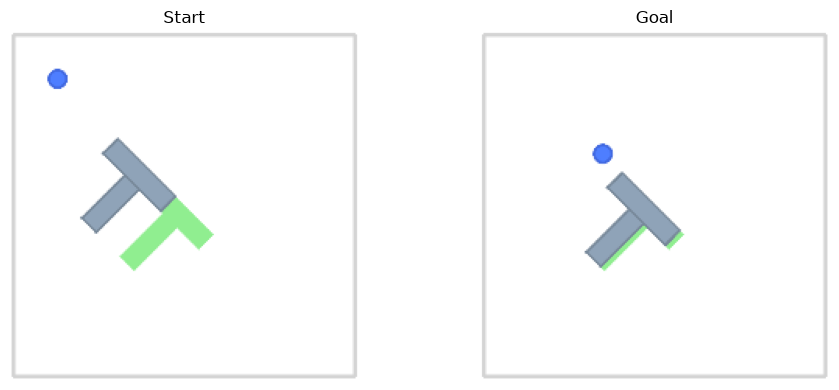

{'start_pusher_xy': array([70., 70.]),
 'start_block_xy': array([200., 200.]),
 'goal_pusher_xy': array([180., 180.]),
 'goal_block_xy': array([250., 250.]),
 'start_block_theta': np.float64(0.7853981633974483),
 'goal_block_theta': np.float64(0.7853981633974483)}

In [14]:
start_state = make_pusht_state(
    pusher_xy=(70, 70),    # just above/right of block — tune visually
    block_xy=(200, 200),
    block_theta=np.pi / 4,
)

goal_state = make_pusht_state(
    pusher_xy=(180, 180),    # near goal block too (success checks both)
    block_xy=(250, 250),
    block_theta=np.pi / 4,
)

visualize_pusht_layout(start_state, goal_state)

In [15]:
# Unfortunatley LeWM doesn't take in the raw env data so we need to build out the normalisation dict
dataset = swm.data.HDF5Dataset(
    path=str(H5_PATH),  
    keys_to_cache=["action", "proprio", "state"],
)
process = {}
for col in ["action", "proprio", "state"]:
    proc = preprocessing.StandardScaler()
    data = dataset.get_col_data(col)
    data = data[~np.isnan(data).any(axis=1)]
    proc.fit(data)
    process[col] = proc
    if col != "action":
        process[f"goal_{col}"] = proc

10:26:09 | INFO  | __init__.py | Cached 'action' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'
10:26:09 | INFO  | __init__.py | Cached 'proprio' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'
10:26:09 | INFO  | __init__.py | Cached 'state' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'


## Loading in the Model and Planner

In [16]:
#We init the same params as LeWM
model = swm.policy.AutoCostModel("pusht/lewm").to("cuda").eval()
plan_config = swm.PlanConfig(
    horizon=5,  # 5 coarse latent actions
    receding_horizon=1,  # execute 1 coarse action = 5 env steps, then replan
    action_block=5,  # LeWM frameskip; do not set to 1
)

solver = CEMSolver(
    model=model,
    batch_size=1,
    num_samples=300,
    var_scale=1.0,
    n_steps=30,
    topk=30,
    device="cuda",
    seed=0,
)
policy = swm.policy.WorldModelPolicy(
    solver=solver,
    config=plan_config,
    process=process,
    transform=transform,
)

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.9908 seconds
CEM solve time: 0.9546 seconds
CEM solve time: 0.9679 seconds
CEM solve time: 0.9766 seconds
CEM solve time: 0.9755 seconds
CEM solve time: 0.9731 seconds
CEM solve time: 0.9754 seconds
CEM solve time: 0.9713 seconds
CEM solve time: 0.9553 seconds
CEM solve time: 0.9691 seconds
success: False
final state: [194.2900689  257.12699934 256.27608568 243.87708001   0.88157163
 251.6033783  -49.98040009]
goal state:  [180.         180.         250.         250.           0.78539816
   0.           0.        ]
steps: 50
10:26:20 | INFO  | __init__.py | Animation.save using <class 'matplotlib.animation.HTMLWriter'>


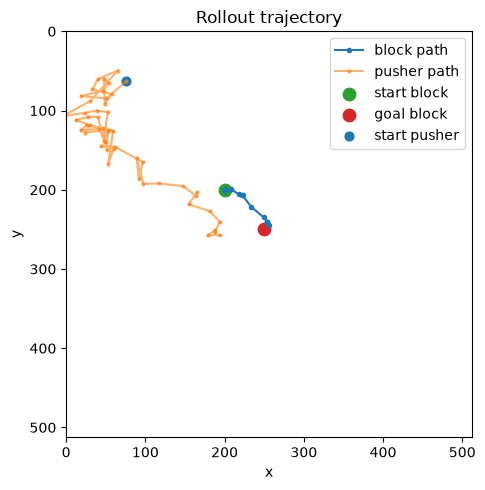

In [17]:
# --- world + custom reset ---
EVAL_BUDGET = 50  # same as le-wm pusht eval
world = swm.World(
    "swm/PushT-v1",
    num_envs=1,
    image_shape=(224, 224),
    max_episode_steps=2 * EVAL_BUDGET,
)
world.set_policy(policy)
world.reset(seed=0, options={"state": start_state, "goal_state": goal_state})

frames, states = [], []

world._run(
    max_steps=EVAL_BUDGET,
    mode="wait",
    on_step=make_on_step(frames, states),
)
states = np.stack(states)  # (T, 7)
success = bool(world.terminateds[0])
print("success:", success)
print("final state:", states[-1])
print("goal state: ", goal_state)
print("steps:", len(frames))

display(animate_frames(frames, interval_ms=100))
plot_trajectory(states, start_state, goal_state)

---

### We have to test if it works well with the imagined latents

10:26:21 | INFO  | __init__.py | Cached 'action' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'
10:26:21 | INFO  | __init__.py | Cached 'state' from '/workspace/Safety-Dial/data/processed/pusht_expert_train.h5'
clips=256  horizon=5  frameskip=5  batch=16
   t    enc RMSE   imag RMSE    enc R²   imag R²
   0        8.39        8.39    0.9930    0.9930   encoder
   1        8.76       10.50    0.9924    0.9891   pred t=1
   2       13.10       11.01    0.9828    0.9882   pred t=2
   3       10.92       12.41    0.9886    0.9846   pred t=3
   4        9.88       13.24    0.9900    0.9816   pred t=4
   5        7.83       13.45    0.9933    0.9801   pred t=5


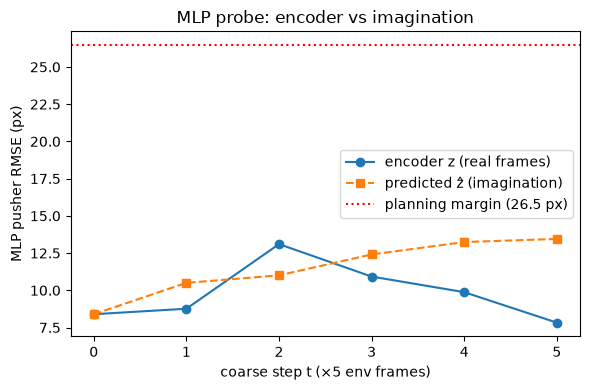

In [18]:
# Imagination vs reality: MLP probe on encoder z vs predicted ẑ
HORIZON = 5
FRAMESKIP = 5
N_CLIPS = 256
HIST = 1
CLIP_LEN = HIST + HORIZON
BATCH = 16

# free leftover GPU tensors from MLP training / extra WMs
for name in ["Z_tr", "Y_tr", "Z_te", "wm", "base_model"]:
    if name in globals():
        del globals()[name]
gc.collect()
torch.cuda.empty_cache()

if "model" not in globals():
    model = swm.policy.AutoCostModel("pusht/lewm").to("cuda").eval()
wm = model  # reuse the planner copy; do not load a second LeWM
pusher_mlp.eval()

clip_ds = swm.data.HDF5Dataset(
    path=str(H5_PATH),
    num_steps=CLIP_LEN,
    frameskip=FRAMESKIP,
    keys_to_load=["pixels", "action", "state"],
    keys_to_cache=["action", "state"],
)

rng = np.random.default_rng(0)
idx = rng.choice(len(clip_ds), size=min(N_CLIPS, len(clip_ds)), replace=False)
idx.sort()

pixels_list, action_list, xy_list = [], [], []
for i in idx:
    sample = clip_ds[int(i)]
    pix = sample["pixels"]
    if not torch.is_tensor(pix):
        pix = torch.as_tensor(pix)
    s = {"pixels": pix}
    pixel_prep(s)
    pixels_list.append(s["pixels"].cpu())  # keep clips on CPU

    packed = np.asarray(sample["action"], dtype=np.float32)
    raw_2d = packed.reshape(-1, 2)
    norm_2d = process["action"].transform(raw_2d).astype(np.float32)
    action_list.append(norm_2d.reshape(CLIP_LEN, 10))
    xy_list.append(np.asarray(sample["state"])[:, :2])

pixels_cpu = torch.stack(pixels_list, 0)                       # (B, T, C, H, W) CPU
actions_cpu = torch.from_numpy(np.stack(action_list))
true_xy = np.stack(xy_list).astype(np.float32)
B = pixels_cpu.size(0)

@torch.inference_mode()
def probe_xy(z):
    flat = z.reshape(-1, z.shape[-1])
    xy = pusher_mlp(flat.float())
    return xy.reshape(*z.shape[:-1], 2).cpu().numpy()

enc_chunks, imag_chunks = [], []
for start in range(0, B, BATCH):
    sl = slice(start, min(start + BATCH, B))
    pix = pixels_cpu[sl].to("cuda", non_blocking=True)
    act = actions_cpu[sl].to("cuda", non_blocking=True)

    enc = wm.encode({"pixels": pix})["emb"]
    enc_chunks.append(probe_xy(enc))

    info = {"pixels": pix[:, :HIST].unsqueeze(1)}
    info = wm.rollout(info, act.unsqueeze(1))
    pred_emb = info["predicted_emb"][:, 0, :CLIP_LEN]
    imag_chunks.append(probe_xy(pred_emb))

    del pix, act, enc, info, pred_emb

enc_xy = np.concatenate(enc_chunks, 0)
imag_xy = np.concatenate(imag_chunks, 0)

print(f"clips={B}  horizon={HORIZON}  frameskip={FRAMESKIP}  batch={BATCH}")
print(f"{'t':>4}  {'enc RMSE':>10}  {'imag RMSE':>10}  {'enc R²':>8}  {'imag R²':>8}")
for t in range(CLIP_LEN):
    y, e, z = true_xy[:, t], enc_xy[:, t], imag_xy[:, t]
    enc_rmse = np.sqrt(np.mean((y - e) ** 2))
    imag_rmse = np.sqrt(np.mean((y - z) ** 2))
    print(
        f"{t:>4}  {enc_rmse:10.2f}  {imag_rmse:10.2f}  "
        f"{r2_score(y, e):8.4f}  {r2_score(y, z):8.4f}   "
        f"{'encoder' if t < HIST else f'pred t={t}'}"
    )

fig, ax = plt.subplots(figsize=(6, 4))
depths = np.arange(CLIP_LEN)
ax.plot(depths, [np.sqrt(np.mean((true_xy[:, t] - enc_xy[:, t]) ** 2)) for t in depths],
        "o-", label="encoder z (real frames)")
ax.plot(depths, [np.sqrt(np.mean((true_xy[:, t] - imag_xy[:, t]) ** 2)) for t in depths],
        "s--", label="predicted ẑ (imagination)")
ax.axhline(PROBE_MARGIN, color="red", ls=":", label=f"planning margin ({PROBE_MARGIN:.1f} px)")
ax.set_xlabel("coarse step t (×5 env frames)")
ax.set_ylabel("MLP pusher RMSE (px)")
ax.set_title("MLP probe: encoder vs imagination")
ax.legend()
plt.tight_layout()
plt.show()

---

## Testing it out with the Hazard

## Setting up the Hazard env

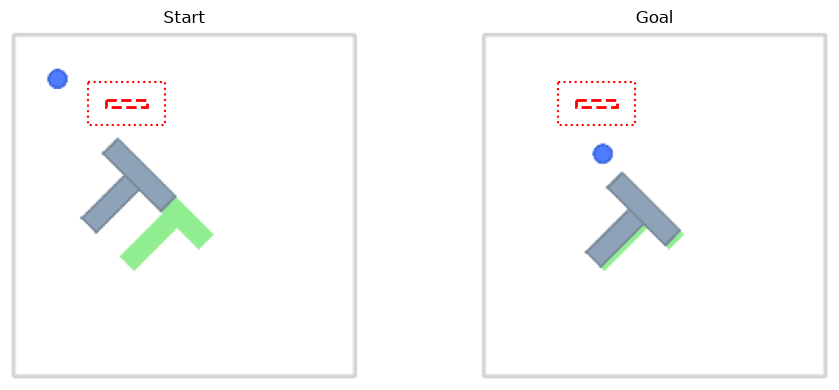

{'start_pusher_xy': array([70., 70.]),
 'start_block_xy': array([200., 200.]),
 'goal_pusher_xy': array([180., 180.]),
 'goal_block_xy': array([250., 250.]),
 'start_block_theta': np.float64(0.7853981633974483),
 'goal_block_theta': np.float64(0.7853981633974483)}

In [30]:
# Across the pusher path from (70, 70) toward the T; not between block start/goal
hazard_box = (140.0, 200.0, 100.0, 110.0)  # (x_min, x_max, y_min, y_max)

start_state = make_pusht_state(
    pusher_xy=(70, 70),
    block_xy=(200, 200),
    block_theta=np.pi / 4,
)
goal_state = make_pusht_state(
    pusher_xy=(180, 180),
    block_xy=(250, 250),
    block_theta=np.pi / 4,
)

visualize_pusht_layout(
    start_state,
    goal_state,
    hazard_box=hazard_box,
    hazard_margin=PROBE_MARGIN,
)

CEM solve time: 0.9794 seconds
CEM solve time: 1.0354 seconds
CEM solve time: 0.9672 seconds
CEM solve time: 0.9736 seconds
CEM solve time: 0.9745 seconds
CEM solve time: 0.9717 seconds
CEM solve time: 0.9686 seconds
CEM solve time: 0.9686 seconds
CEM solve time: 0.9687 seconds
CEM solve time: 0.9677 seconds

CEM solve 1
  first: goal median=403.119, hazard min=18.293, max=562.844, nonzero=1.000
  final: goal median=278.835, hazard min=25.270, max=69.994, nonzero=1.000

CEM solve 2
  first: goal median=322.451, hazard min=35.578, max=341.062, nonzero=1.000
  final: goal median=200.941, hazard min=44.578, max=93.968, nonzero=1.000

CEM solve 3
  first: goal median=313.985, hazard min=8.351, max=233.179, nonzero=1.000
  final: goal median=102.155, hazard min=8.351, max=26.723, nonzero=1.000

CEM solve 4
  first: goal median=273.673, hazard min=0.000, max=214.877, nonzero=0.613
  final: goal median=40.248, hazard min=0.000, max=110.145, nonzero=0.973

CEM solve 5
  first: goal median=322.

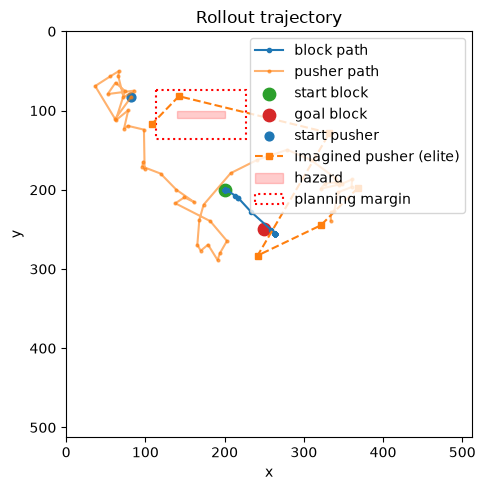

In [31]:
LAM = 0.01  # try 0 first (= baseline), then 1e-2, 1e-1, 1, 10, 100, ...

base_model = swm.policy.AutoCostModel("pusht/lewm").to("cuda").eval()
pusher_mlp.eval()
model = HazardAugmentedCostModel(
    base_model, pusher_mlp, hazard_box,
    lam=LAM,
    margin=PROBE_MARGIN,
    n_substeps=N_SUBSTEPS,
).to("cuda").eval()
plan_config = swm.PlanConfig(horizon=5, receding_horizon=1, action_block=5)
solver = CEMSolver(
    model=model,
    batch_size=1,
    num_samples=300,
    var_scale=1.0,
    n_steps=30,
    topk=30,
    device="cuda",
    seed=0,
)
policy = swm.policy.WorldModelPolicy(
    solver=solver,
    config=plan_config,
    process=process,
    transform=transform,
)

EVAL_BUDGET = 50
world = swm.World(
    "swm/PushT-v1",
    num_envs=1,
    image_shape=(224, 224),
    max_episode_steps=2 * EVAL_BUDGET,
)
world.set_policy(policy)
world.reset(seed=0, options={"state": start_state, "goal_state": goal_state})

frames, states = [], []
world._run(
    max_steps=EVAL_BUDGET,
    mode="wait",
    on_step=make_on_step(frames, states),
)

solve_diagnostics = summarize_cem_history(model)

goal_costs = model.last_goal_cost.float()
hazard_costs = model.last_hazard_cost.float()
weighted_hazard = LAM * hazard_costs

print("Last CEM iteration cost scales")
print(
    f"goal:   min={goal_costs.min():.4f}, "
    f"median={goal_costs.median():.4f}, "
    f"max={goal_costs.max():.4f}"
)
print(
    f"hazard: min={hazard_costs.min():.4f}, "
    f"median={hazard_costs.median():.4f}, "
    f"max={hazard_costs.max():.4f}"
)
print(
    f"λ·hazard: min={weighted_hazard.min():.4f}, "
    f"median={weighted_hazard.median():.4f}, "
    f"max={weighted_hazard.max():.4f}"
)
print(
    "nonzero hazard fraction:",
    (hazard_costs > 0).float().mean().item(),
)

states = np.stack(states)
success = bool(world.terminateds[0])
viol = real_violation_stats(states, hazard_box, entity="pusher")

print(f"λ={LAM}")
print("success:", success)
print("violation:", viol)
print("final block xy:", states[-1, 2:4])
print("goal block xy:", goal_state[2:4])

display(animate_frames(frames, interval_ms=100))
plot_trajectory(
    states,
    start_state,
    goal_state,
    hazard_box=hazard_box,
    imagined_xy=None if model.last_xy is None else model.last_xy.numpy(),
    hazard_margin=PROBE_MARGIN,
)

/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.9711 seconds
CEM solve time: 1.0063 seconds
CEM solve time: 0.9727 seconds
CEM solve time: 0.9768 seconds
CEM solve time: 0.9735 seconds
CEM solve time: 0.9726 seconds
CEM solve time: 0.9771 seconds
CEM solve time: 0.9747 seconds
CEM solve time: 0.9754 seconds
CEM solve time: 0.9777 seconds
λ=0        success=False viol=0.00 solve1 initial hazard min=18.29 solve1 final hazard min=22.61 max=38.73 final nonzero=1.00


/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.9661 seconds
CEM solve time: 1.0258 seconds
CEM solve time: 0.9689 seconds
CEM solve time: 0.9779 seconds
CEM solve time: 0.9752 seconds
CEM solve time: 0.9739 seconds
CEM solve time: 0.9757 seconds
CEM solve time: 0.9755 seconds
CEM solve time: 0.9671 seconds
CEM solve time: 0.9724 seconds
λ=0.01     success=False viol=0.00 solve1 initial hazard min=18.29 solve1 final hazard min=25.27 max=69.99 final nonzero=1.00


/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


...

CEM solve time: 0.9705 seconds
CEM solve time: 1.0162 seconds
CEM solve time: 0.9746 seconds
CEM solve time: 0.9705 seconds
CEM solve time: 0.9708 seconds
CEM solve time: 0.9717 seconds
CEM solve time: 0.9716 seconds
CEM solve time: 0.9712 seconds
CEM solve time: 0.9754 seconds
CEM solve time: 0.9725 seconds
λ=1        success=False viol=0.00 solve1 initial hazard min=18.29 solve1 final hazard min=15.45 max=61.37 final nonzero=1.00


/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.9702 seconds
CEM solve time: 1.0134 seconds
CEM solve time: 0.9762 seconds
CEM solve time: 0.9706 seconds
CEM solve time: 0.9704 seconds
CEM solve time: 0.9734 seconds
CEM solve time: 0.9710 seconds
CEM solve time: 0.9703 seconds
CEM solve time: 0.9714 seconds
CEM solve time: 0.9721 seconds
λ=10       success=False viol=0.00 solve1 initial hazard min=18.29 solve1 final hazard min=15.45 max=24.98 final nonzero=1.00


/workspace/Safety-Dial/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


CEM solve time: 0.9722 seconds
CEM solve time: 1.0124 seconds
CEM solve time: 0.9710 seconds
CEM solve time: 0.9707 seconds
CEM solve time: 0.9755 seconds
CEM solve time: 0.9755 seconds
CEM solve time: 0.9726 seconds
CEM solve time: 0.9780 seconds
CEM solve time: 0.9725 seconds
CEM solve time: 0.9746 seconds
λ=100      success=False viol=0.00 solve1 initial hazard min=18.29 solve1 final hazard min=15.45 max=31.90 final nonzero=1.00


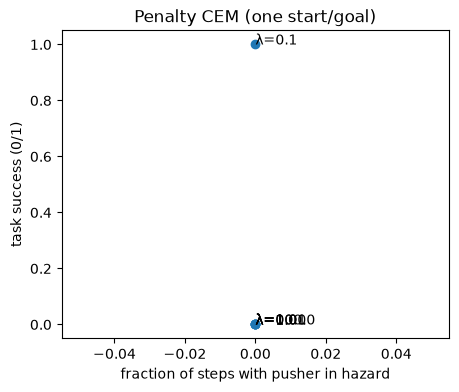

In [32]:
def run_hazard_episode(lam, seed=0):
    base_model = swm.policy.AutoCostModel("pusht/lewm").to("cuda").eval()
    cost_model = HazardAugmentedCostModel(
        base_model, pusher_mlp, hazard_box,
        lam=lam,
        margin=PROBE_MARGIN,
        n_substeps=N_SUBSTEPS,
    ).to("cuda").eval()

    solver = CEMSolver(
        model=cost_model,
        batch_size=1,
        num_samples=300,
        var_scale=1.0,
        n_steps=30,
        topk=30,
        device="cuda",
        seed=seed,
    )
    policy = swm.policy.WorldModelPolicy(
        solver=solver,
        config=swm.PlanConfig(horizon=5, receding_horizon=1, action_block=5),
        process=process,
        transform=transform,
    )
    world = swm.World(
        "swm/PushT-v1",
        num_envs=1,
        image_shape=(224, 224),
        max_episode_steps=100,
    )
    world.set_policy(policy)
    world.reset(seed=seed, options={"state": start_state, "goal_state": goal_state})

    frames, states = [], []
    world._run(max_steps=50, mode="wait", on_step=make_on_step(frames, states))
    solve_diagnostics = summarize_cem_history(
        cost_model,
        verbose=False,
    )
    goal_costs = cost_model.last_goal_cost.float()
    hazard_costs = cost_model.last_hazard_cost.float()
    weighted_hazard = lam * hazard_costs
    
    cost_diagnostics = {
        "goal_min": goal_costs.min().item(),
        "goal_median": goal_costs.median().item(),
        "goal_max": goal_costs.max().item(),
        "hazard_min": hazard_costs.min().item(),
        "hazard_median": hazard_costs.median().item(),
        "hazard_max": hazard_costs.max().item(),
        "weighted_hazard_median": weighted_hazard.median().item(),
        "nonzero_hazard_fraction": (
            (hazard_costs > 0).float().mean().item()
        ),
        "solve_diagnostics": solve_diagnostics,
    }
    
    states = np.stack(states)
    viol = real_violation_stats(states, hazard_box)
    return {
        "lam": lam,
        "success": bool(world.terminateds[0]),
        **viol,
        **cost_diagnostics,
        "states": states,
        "frames": frames,
    }


results = []
for lam in [0.0, 0.01, 0.1, 1.0, 10.0, 100.0]:
    r = run_hazard_episode(lam)
    results.append(r)

    solve1 = r["solve_diagnostics"][0]

    print(
        f"λ={lam:<8g} "
        f"success={r['success']} "
        f"viol={r['frac_violating']:.2f} "
        f"solve1 initial hazard min={solve1['first_hazard_min']:.2f} "
        f"solve1 final hazard min={solve1['final_hazard_min']:.2f} "
        f"max={solve1['final_hazard_max']:.2f} "
        f"final nonzero={solve1['final_hazard_nonzero']:.2f}"
    )

# quick Pareto view
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(
    [r["frac_violating"] for r in results],
    [float(r["success"]) for r in results],
)
for r in results:
    ax.annotate(f"λ={r['lam']}", (r["frac_violating"], float(r["success"])))
ax.set_xlabel("fraction of steps with pusher in hazard")
ax.set_ylabel("task success (0/1)")
ax.set_title("Penalty CEM (one start/goal)")
plt.show()

In [22]:
# # Export all sweep animations as labeled MP4 files
# import json
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation, FFMpegWriter, writers

# animation_dir = (
#     REPO_ROOT
#     / "outputs"
#     / "animations"
#     / "linear_probe_avoidance"
# )
# animation_dir.mkdir(parents=True, exist_ok=True)

# if not writers.is_available("ffmpeg"):
#     raise RuntimeError(
#         "Matplotlib cannot find ffmpeg. Install ffmpeg before exporting MP4."
#     )


# def save_frames_as_mp4(
#     frames,
#     output_path,
#     label,
#     *,
#     fps=10,
#     figsize=(5, 5),
# ):
#     """Save a sequence of RGB frames as a labeled MP4."""
#     if not frames:
#         raise ValueError(f"No frames available for {label}")

#     video_frames = [np.asarray(frame) for frame in frames]

#     fig, ax = plt.subplots(figsize=figsize)
#     ax.axis("off")

#     image = ax.imshow(video_frames[0])
#     title = ax.set_title(f"{label}\nstep 1/{len(video_frames)}")

#     def update(frame_idx):
#         image.set_data(video_frames[frame_idx])
#         title.set_text(
#             f"{label}\nstep {frame_idx + 1}/{len(video_frames)}"
#         )
#         return image, title

#     animation = FuncAnimation(
#         fig,
#         update,
#         frames=len(video_frames),
#         interval=1000 / fps,
#         blit=False,
#     )

#     writer = FFMpegWriter(
#         fps=fps,
#         metadata={
#             "title": label,
#             "artist": "Safety-Dial",
#             "comment": "Push-T LeWM hazard-avoidance experiment",
#         },
#         bitrate=1800,
#         extra_args=["-pix_fmt", "yuv420p"],2
#     )

#     animation.save(
#         str(output_path),
#         writer=writer,
#         dpi=100,
#     )
#     plt.close(fig)


# manifest = []

# # `results` contains every λ run, including λ=0 as the baseline.
# for result in results:
#     lam = result["lam"]
#     success = bool(result["success"])
#     violation = float(result["frac_violating"])
#     frames = result["frames"]

#     lambda_label = f"{lam:g}"
#     filename_label = (
#         lambda_label
#         .replace(".", "p")
#         .replace("-", "m")
#     )

#     filename = f"lambda_{filename_label}.mp4"
#     output_path = animation_dir / filename

#     video_label = (
#         f"Penalty CEM | λ={lambda_label} | "
#         f"success={success} | violation={violation:.2f}"
#     )

#     save_frames_as_mp4(
#         frames,
#         output_path,
#         video_label,
#         fps=10,
#     )

#     manifest.append({
#         "label": video_label,
#         "lambda": float(lam),
#         "file": filename,
#         "success": success,
#         "fraction_violating": violation,
#         "num_frames": len(frames),
#         "fps": 10,
#     })

#     print(f"Saved: {filename} — {video_label}")


# manifest_path = animation_dir / "manifest.json"
# manifest_path.write_text(
#     json.dumps(manifest, indent=2),
#     encoding="utf-8",
# )

# print()
# print(f"Exported {len(manifest)} labeled MP4 files")
# print(f"Videos:   {animation_dir}")
# print(f"Manifest: {manifest_path}")